<a href="https://colab.research.google.com/github/joonookwak/Quality-Control-Chart-Analysis/blob/main/CUSUM%2CEWMA%2CT_Square_controlchart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import packages

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tabulate import tabulate
from scipy.stats import beta

# Load dataset

In [ ]:
# load example datas
ex_data1 = pd.read_csv('semiconductor.csv')
#Variable
d2 = [0, 0, 1.128, 1.693, 2.059, 2.326, 2.534, 2.704, 2.847, 2.970, 3.078]

# Tabular CUSUM

In [ ]:
def tabular_cusum(data, h: int = 5, target: int = None, std: int = None):

    period = np.reshape(np.arange(data.shape[0]) + 1, (data.shape[0], 1))
    data = np.reshape(np.array(data), (data.shape[0], 1))

    if target is None:
        target = np.mean(data)

    if std is None:
        rbar = []
        for i in range(data.shape[0] - 1):
            rbar.append(abs(data[i] - data[i + 1]))

        std = np.mean(rbar) / d2[2]

    K = std / 2
    H = std * h
    LCL = - H
    UCL = H
    center = 0

    # numpy array
    c_plus = np.zeros((data.shape[0], 1))
    c_minus = np.zeros((data.shape[0], 1))
    count_p = np.zeros((data.shape[0], 1))
    count_m = np.zeros((data.shape[0], 1))

    for i in range(data.shape[0] - 1):
        c_plus[(i+1)] = max(0, (data[i+1] - (target + K) + c_plus[i]))
        c_minus[(i+1)] = min(0, (data[i+1] - (target - K) + c_minus[i]))

        if c_plus[i+1] > 0:
            count_p[i+1] = count_p[i] + 1

        else:
            count_p[i+1] = 0

        if c_minus[i+1] < 0:
            count_m[i+1] = count_m[i] + 1

        else:
            count_m[i+1] = 0

    tabular_CUSUM = np.hstack((period, data, c_plus, count_p, c_minus, count_m))
    print(tabulate(tabular_CUSUM, headers=['Period', 'Input', 'C_Plus', 'N_Plus', 'C_Minus', 'N_Minus']))
    print(f'K = {K} & H = {H}')

    return c_plus, c_minus, LCL, UCL, center, count_p, count_m


# Statistic and Limits of Tabular CUSUM

In [ ]:
c_plus, c_minus, LCL, UCL, center, count_p, count_m = tabular_cusum(ex_data1['x1'], target=10, std=1)

  Period    Input    C_Plus    N_Plus    C_Minus    N_Minus
--------  -------  --------  --------  ---------  ---------
       1   10.497     0             0      0              0
       2    9.862     0             0      0              0
       3   10.648     0.148         1      0              0
       4   10.02      0             0      0              0
       5    9.736     0             0      0              0
       6   11.538     1.038         1      0              0
       7   10.302     0.84          2      0              0
       8    9.79      0.13          3      0              0
       9    9.539     0             0      0              0
      10   10.365     0             0      0              0
      11    9.018     0             0     -0.482          1
      12   10.318     0             0      0              0
      13    9.756     0             0      0              0
      14   10.13      0             0      0              0
      15    9.227     0             0   

# Tabular CUSUM Control Chart

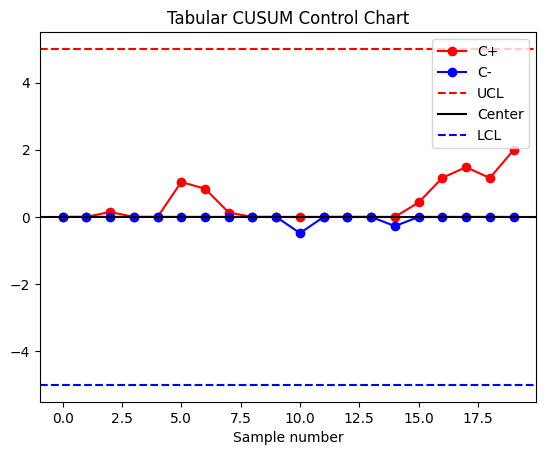

In [ ]:
# fig = plt.figure(figsize=(15, 8))
plt.plot(c_plus, marker='o', color='r', label='C+')
plt.plot(c_minus, marker='o', color='b', label='C-')
plt.axhline(UCL, color='r', label='UCL', linestyle='--')
plt.axhline(center, color='black', label='Center')
plt.axhline(LCL, color='b', label='LCL', linestyle='--')
plt.legend()
plt.title('Tabular CUSUM Control Chart')
plt.xlabel('Sample number')
plt.show()

# Check the first "out of control" period

In [ ]:
for period, c_p in zip(np.arange(ex_data1['x1'].shape[0] + 1), c_plus):
    if c_p > UCL:
        print(f'First "out of control" at period {period}')
        break


# EWMA (Exponentially Weighted Moving Average)

In [ ]:
def EWMA(data, target: int = None, std: int = None, rate: float = None, width: float = None):

    period = np.reshape(np.arange(data.shape[0]) + 1, (data.shape[0], 1))
    data = np.reshape(np.array(data), (data.shape[0], 1))

    if target is None:
        target = np.mean(data)

    if std is None:
        rbar = []
        for i in range(data.shape[0] - 1):
            rbar.append(abs(data[i] - data[i+1]))

        std = np.mean(rbar) / d2[2]

    z = np.zeros((data.shape[0]+1, 1))
    EWMA_UCL = np.zeros((data.shape[0]+1, 1))
    EWMA_LCL = np.zeros((data.shape[0]+1, 1))

    z[0] = target

    for i in range(1, data.shape[0] + 1):
        z[i] = rate * data[i-1] + (1 - rate) * z[i-1]

    for i in range(data.shape[0] + 1):
        EWMA_UCL[i] = target + width * std * np.sqrt(rate/(2-rate) * (1-np.power(1-rate, 2*i)))
        EWMA_LCL[i] = target - width * std * np.sqrt(rate/(2-rate) * (1-np.power(1-rate, 2*i)))

    print(f'Rate = {rate} & Width = {width}')

    print('EWMA Statistics Table')
    tabular_EWMA = np.hstack((period, data, z[1:], EWMA_UCL[1:], EWMA_LCL[1:]))
    print(tabulate(tabular_EWMA, headers = ['Period', 'Input', 'Z_value', 'UCL', 'LCL']))

    return z, EWMA_UCL, EWMA_LCL, target

# Statistic and Limits of EWMA

In [ ]:
z, EWMA_UCL, EWMA_LCL, target = EWMA(ex_data1['x1'], std=1.0, rate=0.2, width=3.)

Rate = 0.2 & Width = 3.0
EWMA Statistics Table
  Period    Input    Z_value      UCL      LCL
--------  -------  ---------  -------  -------
       1   10.497   10.3088   10.8618  9.66175
       2    9.862   10.2194   11.0301  9.49338
       3   10.648   10.3052   11.1207  9.40276
       4   10.02    10.2481   11.174   9.34948
       5    9.736   10.1457   11.2065  9.31696
       6   11.538   10.4242   11.2268  9.29672
       7   10.302   10.3997   11.2395  9.28399
       8    9.79    10.2778   11.2476  9.27592
       9    9.539   10.13     11.2527  9.2708
      10   10.365   10.177    11.256   9.26753
      11    9.018    9.94522  11.2581  9.26545
      12   10.318   10.0198   11.2594  9.26411
      13    9.756    9.96702  11.2602  9.26326
      14   10.13     9.99961  11.2608  9.26272
      15    9.227    9.84509  11.2611  9.26237
      16   10.931   10.0623   11.2614  9.26215
      17   11.232   10.2962   11.2615  9.262
      18   10.82    10.401    11.2616  9.26191
      19   10.17

# EWMA Conrtol Chart

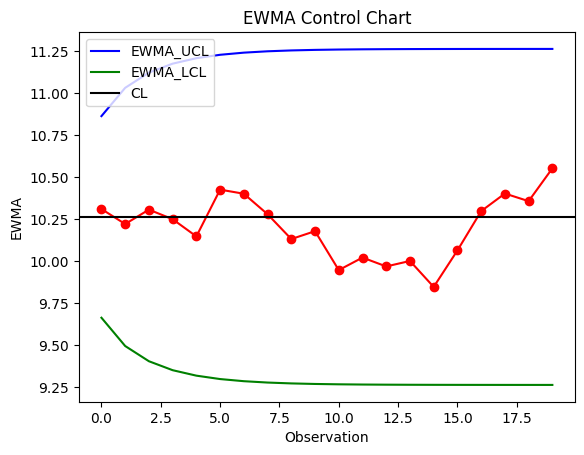

In [ ]:
# fig = plt.figure(figsize=(15, 8))
plt.plot(z[1:], marker='o', color='r')
plt.plot(EWMA_UCL[1:], color='b', label='EWMA_UCL')
plt.plot(EWMA_LCL[1:], color='g', label='EWMA_LCL')
plt.axhline(target, color='black', label='CL')
plt.legend()
plt.title('EWMA Control Chart')
plt.xlabel('Observation')
plt.ylabel('EWMA')
plt.show()

# Check the first "out of control" period

In [ ]:
for period, z_, ucl in zip(np.arange(ex_data1['x1'].shape[0] + 1)[1:], z[1:], EWMA_UCL[1:]):
    if z_ > ucl:
        print(f'First "out of control" at period {period}')
        break

# Multivariate T Square

In [ ]:
def t_square(data, alpha: float = None):

    array_data = np.array(data)
    num_sample = len(data)

    p = array_data.shape[1]

    col_mean = np.mean(array_data, axis=0)  # column mean
    mat_cov = np.cov(array_data.T)  # covariance
    mat_inv_s = np.linalg.inv(mat_cov)  # inverse S

    values = []
    for sample in array_data:
        dif = sample - col_mean
        value = mat_inv_s.dot(dif.T).dot(dif)  # T-square
        values.append(value)

    CL = (np.power((num_sample -1), 2)) / num_sample
    LCL = 0
    UCL = CL * beta.ppf((1-alpha), p/2, (num_sample - p - 1)/2)

    return values, LCL, UCL

# Check the result according to the change of alpha value

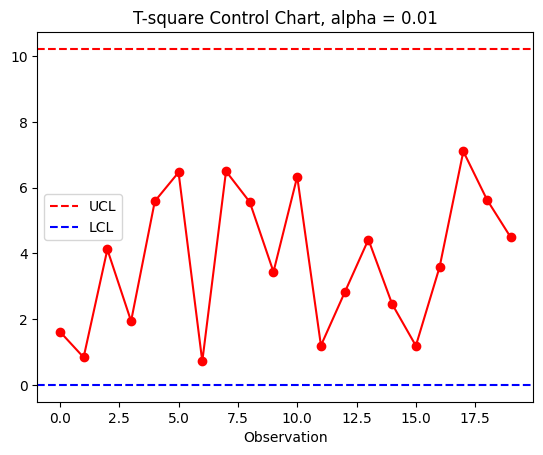

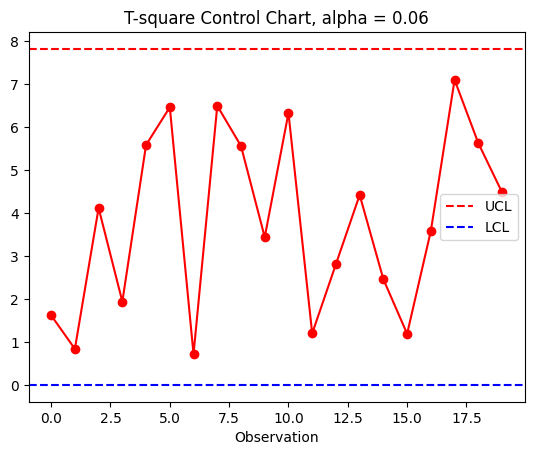

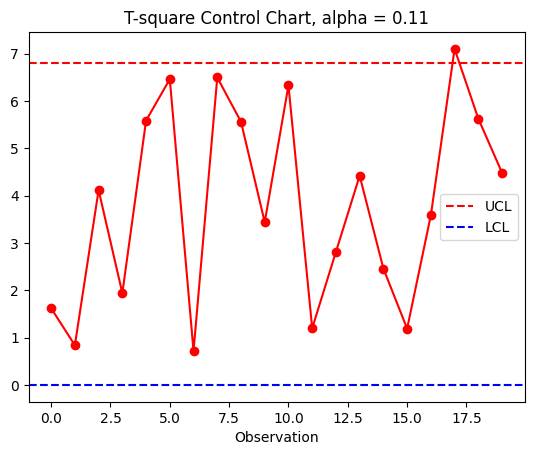

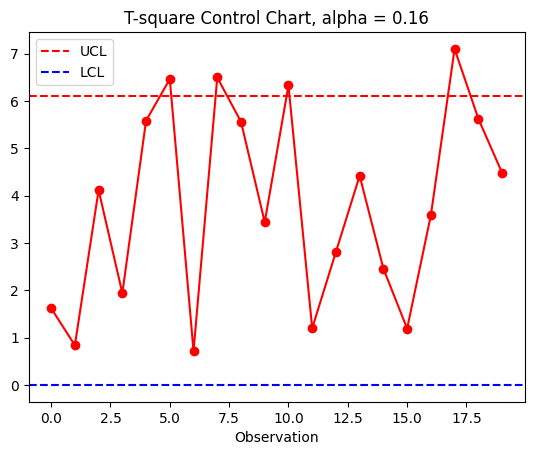

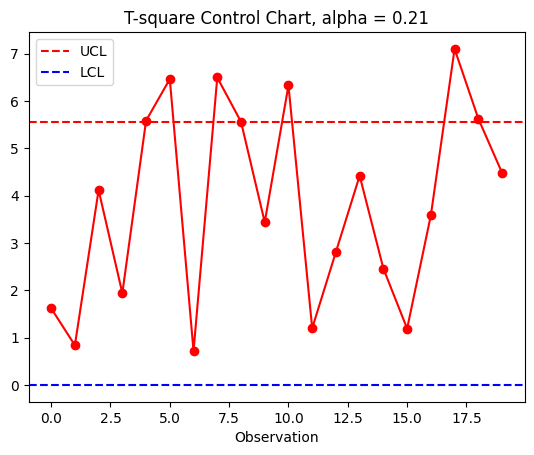

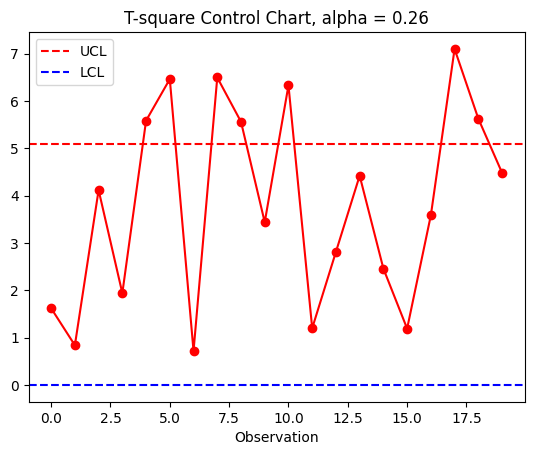

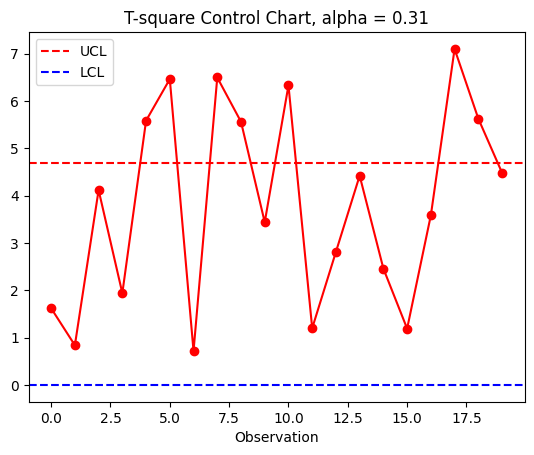

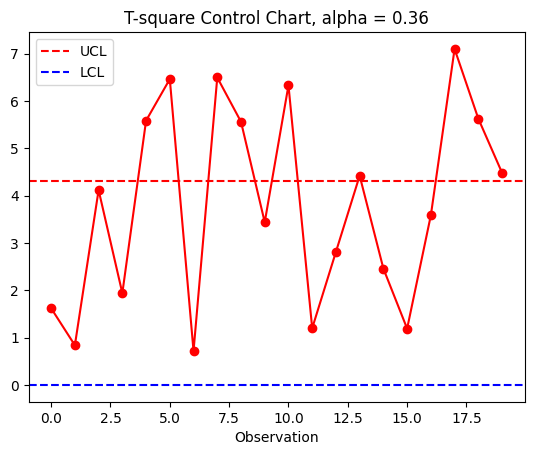

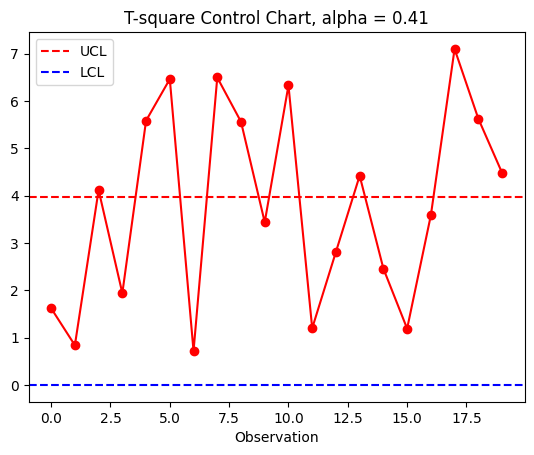

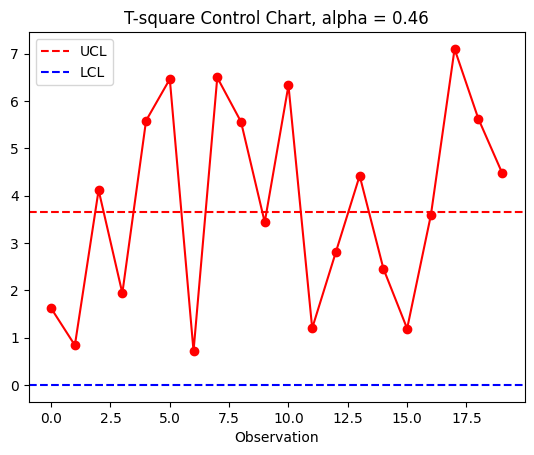

In [ ]:
alphas = np.arange(0.01, 0.5, 0.05)

for alpha in alphas:
    values, LCL, UCL = t_square(ex_data1, alpha=alpha)

    plt.plot(values, marker='o', color='r')
    plt.axhline(UCL, color='r', label='UCL', linestyle='--')
    # plt.axhline(center, color='black', label='Center')
    plt.axhline(LCL, color='b', label='LCL', linestyle='--')
    plt.legend()
    plt.title(f'T-square Control Chart, alpha = {np.round(alpha,3)}')
    plt.xlabel('Observation')
    plt.show()
